# Libraries

In [16]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

# Load Data

In [ ]:
content_df = pd.read_csv(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\content.csv")
interactions_df = pd.read_csv(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\interactions.csv")
users_df = pd.read_excel(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\users.xlsx")

# Content Embeddings

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

content_df['text'] = (
    content_df['category'].astype(str) + " " +
    content_df['level'].astype(str) + " " +
    content_df['description'].astype(str)
)

content_embeddings = model.encode(content_df['text'].tolist())

content_sim = cosine_similarity(content_embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# RETRAIN FUNCTION (SVD)

In [17]:
def retrain_collaborative(interactions_df):

    print("🔁 Retraining Collaborative Model...")

    user_item = interactions_df.pivot_table(
        index='user_id',
        columns='content_id',
        values='rating',
        fill_value=0
    )

    svd = TruncatedSVD(n_components=50, random_state=42)

    user_factors = svd.fit_transform(user_item)
    item_factors = svd.components_

    collab_pred = np.dot(user_factors, item_factors)

    collab_df = pd.DataFrame(
        collab_pred,
        index=user_item.index,
        columns=user_item.columns
    )

    print("✅ Retraining Done!")

    return collab_df, user_item

# Initial Training

In [18]:
collab_df, user_item = retrain_collaborative(interactions_df)

🔁 Retraining Collaborative Model...
✅ Retraining Done!


# Hybrid Recommendation

In [40]:
def hybrid_recommend(user_id, collab_df, top_n=5):

    all_items = content_df['content_id'].values

    # ---------- Content Score ----------
    content_scores = pd.Series(0, index=all_items, dtype=float)

    history = interactions_df[
        interactions_df['user_id'] == user_id
    ]['content_id'].values

    idx = content_df[content_df['content_id'].isin(history)].index

    if len(idx) > 0:
        scores = np.sum(content_sim[idx], axis=0)
        content_scores = pd.Series(scores, index=all_items)

    # ---------- Collaborative Score ----------
    if user_id in collab_df.index:
        collab_scores = collab_df.loc[user_id].reindex(all_items, fill_value=0)
    else:
        collab_scores = pd.Series(0, index=all_items)

    # ---------- Normalization ----------
    scaler = MinMaxScaler()

    content_norm = scaler.fit_transform(
        content_scores.values.reshape(-1,1)
    ).flatten()

    collab_norm = scaler.fit_transform(
        collab_scores.values.reshape(-1,1)
    ).flatten()

    # ---------- Final Score ----------
    final_score = 0.5 * content_norm + 0.5 * collab_norm

    result = pd.DataFrame({
        "content_id": all_items,
        "score": final_score
    })

    result = result.merge(content_df, on="content_id")
    result = result.sort_values("score", ascending=False)

    return result.head(top_n)

# evaluate

In [41]:
def evaluate_model(collab_df):

    users = interactions_df['user_id'].unique()[:50]

    precisions, recalls, f1s = [], [], []

    for u in users:

        recs = hybrid_recommend(u, collab_df)['content_id'].tolist()

        actual = interactions_df[
            (interactions_df['user_id'] == u) &
            (interactions_df['rating'] >= 3)
        ]['content_id'].tolist()

        if len(actual) == 0:
            continue

        k = 5

        precision = len(set(recs[:k]) & set(actual)) / k
        recall = len(set(recs[:k]) & set(actual)) / len(actual)

        f1 = 0 if (precision + recall) == 0 else 2*(precision*recall)/(precision+recall)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return np.mean(precisions), np.mean(recalls), np.mean(f1s)

#  BEFORE RETRAIN

In [42]:
collab_before = collab_df.copy()

before_metrics = evaluate_model(collab_before)

# BIG DATA SIMULATION (Optional)

In [43]:
new_data = pd.DataFrame({
    "user_id": np.random.randint(1, 500, 20000),
    "content_id": np.random.randint(1, 200, 20000),
    "rating": np.random.randint(1, 6, 20000)
})

interactions_updated = pd.concat([interactions_df, new_data])

# AFTER RETRAIN


In [44]:
collab_after, user_item_after = retrain_collaborative(interactions_updated)

after_metrics = evaluate_model(collab_after)

🔁 Retraining Collaborative Model...
✅ Retraining Done!


# RESULTS COMPARISON

In [45]:
print("📊 BEFORE RETRAIN")
print("Precision:", before_metrics[0])
print("Recall:", before_metrics[1])
print("F1:", before_metrics[2])

print("\n📊 AFTER RETRAIN")
print("Precision:", after_metrics[0])
print("Recall:", after_metrics[1])
print("F1:", after_metrics[2])


📊 BEFORE RETRAIN
Precision: 0.7240000000000001
Recall: 0.09113419083394295
F1: 0.15379673289029377

📊 AFTER RETRAIN
Precision: 0.74
Recall: 0.09130185777174762
F1: 0.15511280052336265


# PLOT COMPARISON

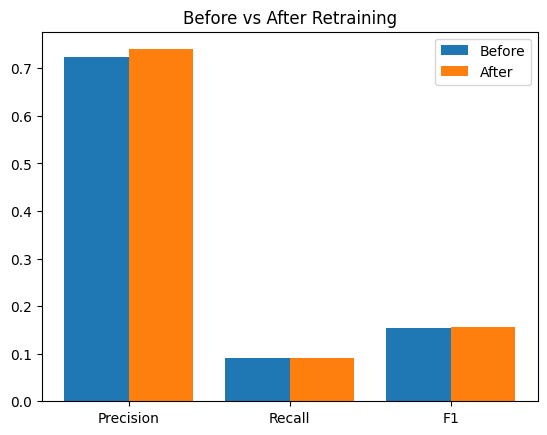

In [53]:
import matplotlib.pyplot as plt

labels = ["Precision", "Recall", "F1"]

plt.bar(np.arange(3)-0.2, before_metrics, 0.4, label="Before")
plt.bar(np.arange(3)+0.2, after_metrics, 0.4, label="After")

plt.xticks(np.arange(3), labels)
plt.title("Before vs After Retraining")
plt.legend()
plt.show()

# TEST RECOMMENDATION

In [49]:
print(hybrid_recommend(1, collab_after))

      content_id     score                                title  \
123          124  0.806902  Mobile App Development with Flutter   
137          138  0.801262       Introduction to Cyber Security   
1970        1971  0.667639                 Python for Beginners   
186          187  0.663045        Deep Learning with TensorFlow   
48            49  0.646803                Data Science Bootcamp   

                                            description         category  \
123   Master advanced techniques and industry best p...  Cloud Computing   
137   Step-by-step guide to becoming a professional ...     Data Science   
1970  Advanced course for professionals aiming to up...   Cyber Security   
186   Advanced course for professionals aiming to up...     Data Science   
48    Perfect for beginners looking to start their j...     Data Science   

             level  duration  difficulty  rating  \
123       Beginner       185           2    2.78   
137       Beginner       116        